In [1]:
!pip install -r ../requirements.txt

In [2]:
import sys
import importlib
import numpy as np
sys.path.append("..")

# Import your modules first
import helper
import obelix
import algorithms.d3qn_per_agent as d3qn_per_agent
import configurations.config_p2_sub2 as config_path

# Reload them to pick up any changes
importlib.reload(helper)
importlib.reload(obelix)
importlib.reload(d3qn_per_agent)
importlib.reload(config_path)

device used:  cuda
device used:  cuda


<module 'configurations.config_p2_sub2' from 'c:\\Users\\hgoel\\MTech_Resources\\DRL\\Capstone_Project\\CS780-OBELIX\\run_scripts\\..\\configurations\\config_p2_sub2.py'>

In [3]:
from helper import plotQuantity
from obelix import OBELIX
from algorithms.d3qn_per_agent import D3QN_PER
from configurations.config_p2_sub2 import config

In [4]:
env = OBELIX(
    scaling_factor=5,
    arena_size=500,
    max_steps=1000,
    wall_obstacles=False,
    difficulty=2
)
d3qnPerAgent = D3QN_PER(env, config)

In [5]:
print(config)

{'seed': 333, 'gamma': 0.999, 'bufferSize': 100000, 'batchSize': 32, 'optimizerFn': <class 'torch.optim.adam.Adam'>, 'optimizerLR': 0.0002, 'MAX_TRAIN_EPISODES': 500, 'MAX_EVAL_EPISODES': 1, 'updateFrequency': 500, 'explorationStrategyTrainFn': <function selectEpsilonGreedyAction at 0x0000027F60F17E20>, 'explorationStrategyEvalFn': <function selectGreedyAction at 0x0000027F52D3A340>, 'max_steps': 1000, 'epsilon': 0.58, 'eps_decay_strategy': [('linear', {'s': 0, 'e': 499, 'ival': 1.0, 'fval': 0.0012})], 'device': device(type='cuda'), 'delta': 1.0, 'tau': 0.15, 'alpha': 0.45, 'beta': 0.55, 'beta_rate': 0.0002, 'hDim': [128, 64], 'model_path': '../model_weights_phase2_sub2', 'loss_fn': 'HuberLoss'}


In [6]:
d3qnPerTrainRewardsList, d3qnPerTrainTimeList, d3qnPerEvalRewardsList, d3qnPerWallClockTimeList, d3qnPerTotalStepsList, d3qnPerFinalEvalReward = d3qnPerAgent.runD3QN_PER()

Episode 0: TR -15200.0 | ER -998.0 | TT 16.920218467712402 | WC 24.263433933258057 | TS 1000
Episode 1: TR -967.0 | ER -976.0 | TT 32.42621612548828 | WC 40.06103253364563 | TS 1000
Episode 2: TR -868.0 | ER -1000.0 | TT 48.505568742752075 | WC 55.74501848220825 | TS 1000
Episode 3: TR -32468.0 | ER -972.0 | TT 64.31779170036316 | WC 71.44931817054749 | TS 1000
Episode 4: TR -984.0 | ER -967.0 | TT 79.2523844242096 | WC 85.96612310409546 | TS 1000
Episode 5: TR -975.0 | ER -1000.0 | TT 93.4871084690094 | WC 100.21803450584412 | TS 1000
Episode 6: TR -870.0 | ER -1000.0 | TT 108.26801872253418 | WC 117.6004524230957 | TS 1000
Episode 7: TR -973.0 | ER -972.0 | TT 130.47250866889954 | WC 143.55500745773315 | TS 1000
Episode 8: TR -55800.0 | ER -990.0 | TT 154.87410950660706 | WC 165.43791103363037 | TS 1000
Episode 9: TR -1000.0 | ER -1000.0 | TT 178.76452016830444 | WC 189.3628101348877 | TS 1000
Episode 10: TR -868.0 | ER -972.0 | TT 204.5657935142517 | WC 215.61660170555115 | TS 1000


In [7]:
print(f"D3QN_PER Final Evaluation Reward: {np.mean(d3qnPerFinalEvalReward).item()} +- {np.std(d3qnPerFinalEvalReward).item()}")

D3QN_PER Final Evaluation Reward: -1000.0 +- 0.0


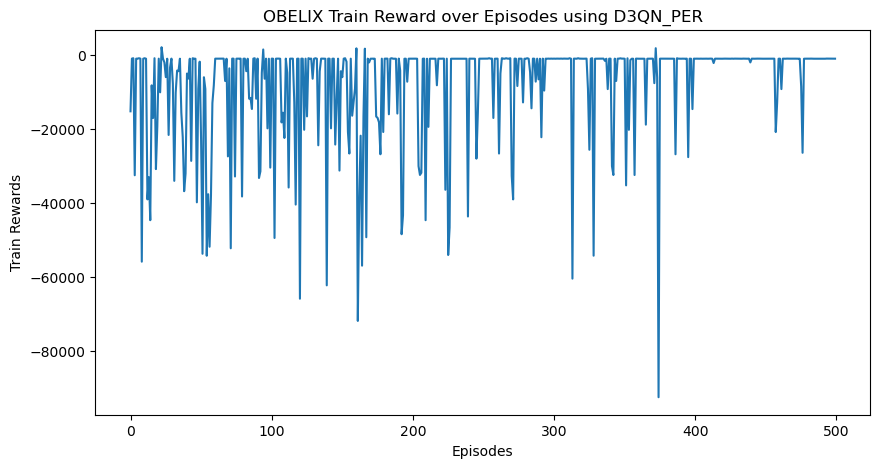

In [8]:
plotQuantity(
    d3qnPerTrainRewardsList, 
    len(d3qnPerTrainRewardsList), 
    descriptionList = ["Episodes", "Train Rewards", "OBELIX Train Reward over Episodes using D3QN_PER"]    
)

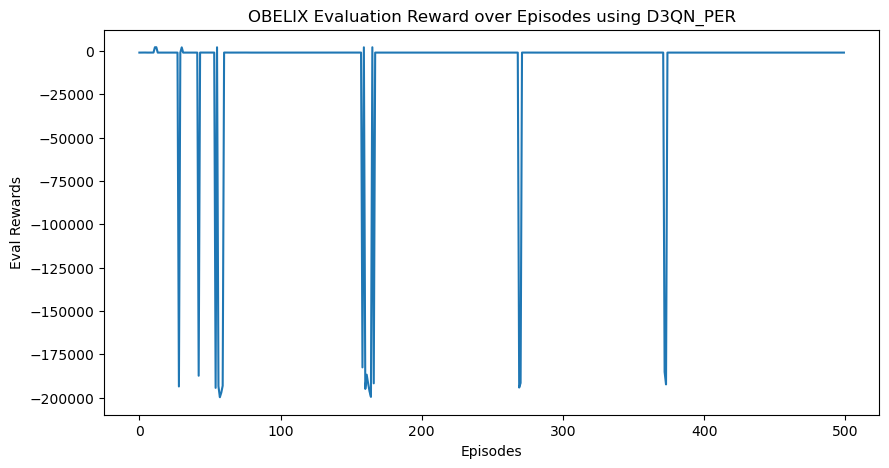

In [9]:
plotQuantity(
    d3qnPerEvalRewardsList, 
    len(d3qnPerEvalRewardsList), 
    descriptionList = ["Episodes", "Eval Rewards", "OBELIX Evaluation Reward over Episodes using D3QN_PER"]    
)

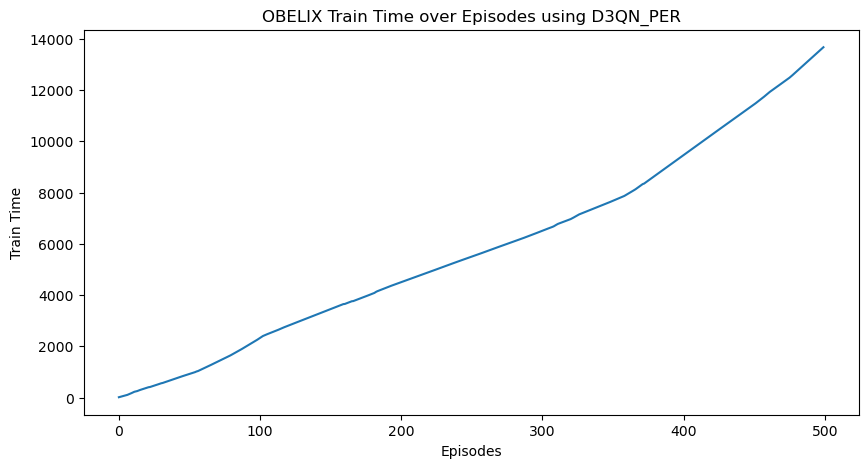

In [10]:
plotQuantity(
    d3qnPerTrainTimeList, 
    len(d3qnPerTrainTimeList), 
    descriptionList = ["Episodes", "Train Time", "OBELIX Train Time over Episodes using D3QN_PER"]    
)

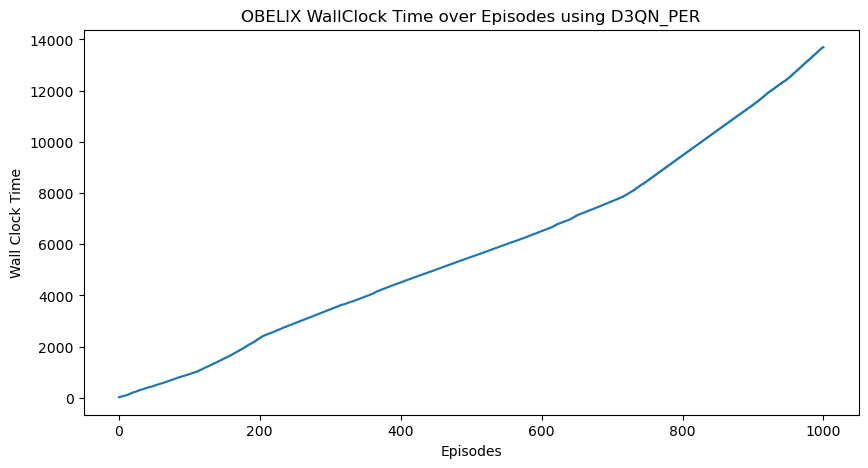

In [11]:
plotQuantity(
    d3qnPerWallClockTimeList, 
    len(d3qnPerWallClockTimeList), 
    descriptionList = ["Episodes", "Wall Clock Time", "OBELIX WallClock Time over Episodes using D3QN_PER"]    
)

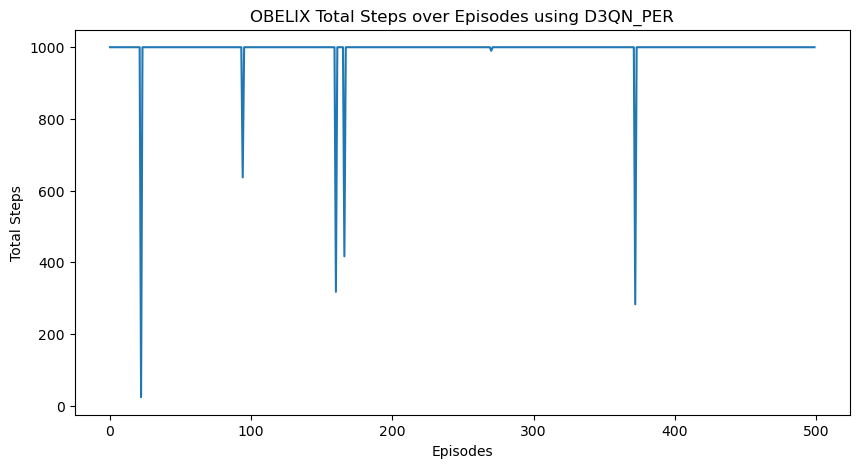

In [12]:
plotQuantity(
    d3qnPerTotalStepsList, 
    len(d3qnPerTotalStepsList), 
    descriptionList = ["Episodes", "Total Steps", "OBELIX Total Steps over Episodes using D3QN_PER"]    
)